# File for cleanly and succinctly processing the USGS data 
previous files (APIpull and chilock) for very initial EDA


In [33]:
import pandas as pd
import numpy as np
import glob
import os
import duckdb
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns


In [34]:
#relevant usgs datapaths
datapath = "data/"
gauges_datapath = "data/USGS_gauges/"
precip_datapath = "data/USGS_precip/"

In [35]:
#info about stations
USGS_station_info = pd.read_csv(datapath + "fav_USGS_location.csv")

In [36]:
all_files = glob.glob(os.path.join(precip_datapath, "precip_summer*.csv"))
print(all_files)
li = []

for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df)
print(li)
raw_precip_all = pd.concat(li, axis=0, ignore_index=True)

    

['data/USGS_precip/precip_summer2025USGS-415458087462201.csv', 'data/USGS_precip/precip_summer2021USGS-415118087381201.csv', 'data/USGS_precip/precip_summer2022USGS-415657087382101.csv', 'data/USGS_precip/precip_summer2025USGS-414527087323801.csv', 'data/USGS_precip/precip_summer2024USGS-414542087380901.csv', 'data/USGS_precip/precip_summer2025USGS-415118087381201.csv', 'data/USGS_precip/precip_summer2021USGS-415458087462201.csv', 'data/USGS_precip/precip_summer2024USGS-420119087445101.csv', 'data/USGS_precip/precip_summer2022USGS-415155087451901.csv', 'data/USGS_precip/precip_summer2023USGS-420626087452301.csv', 'data/USGS_precip/precip_summer2021USGS-414527087323801.csv', 'data/USGS_precip/precip_summer2021USGS-415155087451901.csv', 'data/USGS_precip/precip_summer2025USGS-415657087382101.csv', 'data/USGS_precip/precip_summer2022USGS-414527087323801.csv', 'data/USGS_precip/precip_summer2022USGS-415458087462201.csv', 'data/USGS_precip/precip_summer2024USGS-420626087452301.csv', 'data/U

In [37]:
print(len(li)) #its the correct length, got all the dataframes (8 sites, 5 summers for each site)
for df in li:
    print(len(df)) #all dfs are expected lengths, good to concat and then check out the columns all together

40
43771
43771
43768
43771
43772
43771
43765
43773
43772
43772
43768
43773
43772
43771
43772
43774
43772
43773
87543
43773
43763
43772
43772
43771
43772
43772
43771
43771
43773
43773
43772
43773
43773
87546
43775
43773
31302
43772
43774
43770


In [38]:
# quick plot to make sure the data in the dfs is not crazy
# for df in li:
#     df.plot(x="time", y=["value"], figsize=(12, 4),
#             title="precip over time",
#             ylabel="precip", legend=True)
#     plt.tight_layout()
#     plt.show()

In [39]:
print(raw_precip_all.dtypes)
print(raw_precip_all.describe())
display(raw_precip_all)

time_series_id             object
monitoring_location_id     object
parameter_code              int64
statistic_id              float64
time                       object
value                     float64
unit_of_measure            object
approval_status            object
qualifier                 float64
last_modified              object
continuous_id              object
dtype: object
       parameter_code  statistic_id         value  qualifier
count       1825937.0           0.0  1.825937e+06        0.0
mean             45.0           NaN  3.900299e-04        NaN
std               0.0           NaN  5.991653e-03        NaN
min              45.0           NaN  0.000000e+00        NaN
25%              45.0           NaN  0.000000e+00        NaN
50%              45.0           NaN  0.000000e+00        NaN
75%              45.0           NaN  0.000000e+00        NaN
max              45.0           NaN  1.120000e+00        NaN


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,129f1c634520429699c714e227d25378,USGS-415458087462201,45,NaN,2025-05-01 00:00:00+00:00,0.0,in,Approved,NaN,2025-12-18 22:33:32.031944+00:00,018ff163-32e0-4e21-84b4-3e2fcabba37f
1,129f1c634520429699c714e227d25378,USGS-415458087462201,45,NaN,2025-05-01 00:05:00+00:00,0.0,in,Approved,NaN,2025-12-18 22:33:32.031944+00:00,05ad430b-438e-458f-825c-bedde997d5c5
2,129f1c634520429699c714e227d25378,USGS-415458087462201,45,NaN,2025-05-01 00:10:00+00:00,0.0,in,Approved,NaN,2025-12-18 22:33:32.031944+00:00,3a954905-0b3a-48c7-bf5d-54147b6ae4ce
3,129f1c634520429699c714e227d25378,USGS-415458087462201,45,NaN,2025-05-01 00:15:00+00:00,0.0,in,Approved,NaN,2025-12-18 22:33:32.031944+00:00,7a2b4fc9-170c-42be-b312-f91ad49851bd
4,129f1c634520429699c714e227d25378,USGS-415458087462201,45,NaN,2025-05-01 00:20:00+00:00,0.0,in,Approved,NaN,2025-12-18 22:33:32.031944+00:00,4264a7fe-b716-4323-a36e-5c1004be74f2
...,...,...,...,...,...,...,...,...,...,...,...
1825932,408a10d09dc24b68b6aa85dc614a7672,USGS-414527087323801,45,NaN,2023-09-29 23:40:00+00:00,0.0,in,Approved,NaN,2025-07-18 18:11:03.059924+00:00,bf2e3ba7-c386-44fb-8999-4c423cf0ca75
1825933,408a10d09dc24b68b6aa85dc614a7672,USGS-414527087323801,45,NaN,2023-09-29 23:45:00+00:00,0.0,in,Approved,NaN,2025-07-18 18:11:03.059924+00:00,e0a98d86-04b2-4c03-8313-b50501b20f41
1825934,408a10d09dc24b68b6aa85dc614a7672,USGS-414527087323801,45,NaN,2023-09-29 23:50:00+00:00,0.0,in,Approved,NaN,2025-07-18 18:11:03.059924+00:00,be4b4c20-f610-4803-9d10-eada32796b20
1825935,408a10d09dc24b68b6aa85dc614a7672,USGS-414527087323801,45,NaN,2023-09-29 23:55:00+00:00,0.0,in,Approved,NaN,2025-07-18 18:11:03.059924+00:00,c4af5263-988f-47d9-aa93-9e2988cbc251


In [40]:
#the value column is the only column that matters, looks fine but needs digging in and timestamp conversion
# raw_precip_all.plot(x="time", y=["value"], figsize=(12, 4),
#         title="precip over time",
#         ylabel="precip", legend=True)
# plt.tight_layout()
# plt.show()

In [41]:
raw_precip_all['time_utc'] = pd.to_datetime(raw_precip_all['time'], utc=True)

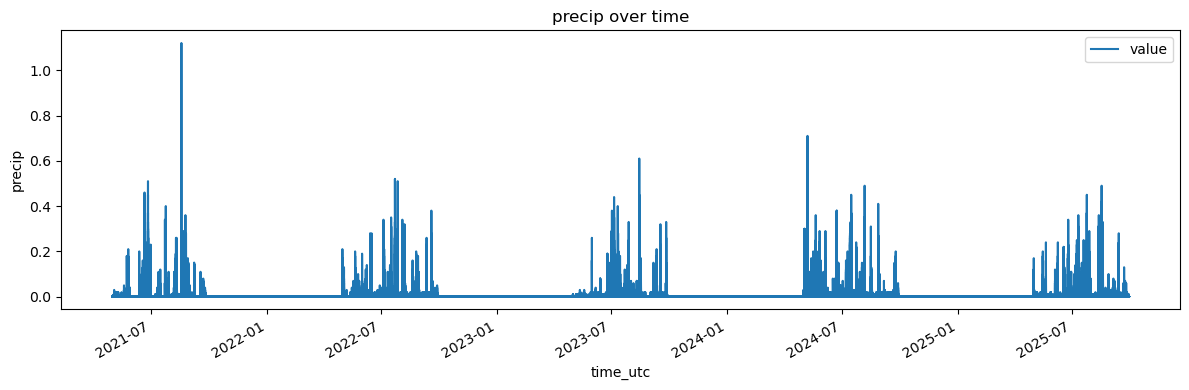

In [42]:
raw_precip_all.plot(x="time_utc", y=["value"], figsize=(12, 4),
        title="precip over time",
        ylabel="precip", legend=True)
plt.tight_layout()
plt.show()

In [43]:
raw_precip_all['timestamp_central'] = raw_precip_all['time_utc'].dt.tz_convert('America/Chicago')
print(raw_precip_all[['monitoring_location_id','value','time','time_utc','timestamp_central']])

        monitoring_location_id  value                       time  \
0         USGS-415458087462201    0.0  2025-05-01 00:00:00+00:00   
1         USGS-415458087462201    0.0  2025-05-01 00:05:00+00:00   
2         USGS-415458087462201    0.0  2025-05-01 00:10:00+00:00   
3         USGS-415458087462201    0.0  2025-05-01 00:15:00+00:00   
4         USGS-415458087462201    0.0  2025-05-01 00:20:00+00:00   
...                        ...    ...                        ...   
1825932   USGS-414527087323801    0.0  2023-09-29 23:40:00+00:00   
1825933   USGS-414527087323801    0.0  2023-09-29 23:45:00+00:00   
1825934   USGS-414527087323801    0.0  2023-09-29 23:50:00+00:00   
1825935   USGS-414527087323801    0.0  2023-09-29 23:55:00+00:00   
1825936   USGS-414527087323801    0.0  2023-09-30 00:00:00+00:00   

                         time_utc         timestamp_central  
0       2025-05-01 00:00:00+00:00 2025-04-30 19:00:00-05:00  
1       2025-05-01 00:05:00+00:00 2025-04-30 19:05:00-05:00

In [44]:
#everything is looking good so far, just need to find null values and other digging (all measurements are in inches, no qualifier flags)
print(raw_precip_all['monitoring_location_id'].unique())
print(raw_precip_all['unit_of_measure'].unique()) 
print(raw_precip_all['qualifier'].unique())
print(raw_precip_all['monitoring_location_id'].isna().sum())

['USGS-415458087462201' 'USGS-415118087381201' 'USGS-415657087382101'
 'USGS-414527087323801' 'USGS-414542087380901' 'USGS-420119087445101'
 'USGS-415155087451901' 'USGS-420626087452301']
['in']
[nan]
0


In [45]:
raw_precip_all = raw_precip_all.rename(columns={'value':'precip_in'})
precip_all = raw_precip_all[['monitoring_location_id','precip_in','timestamp_central']]
precip_all

,monitoring_location_id,precip_in,timestamp_central
0,USGS-415458087462201,0.0,2025-04-30 19:00:00-05:00
1,USGS-415458087462201,0.0,2025-04-30 19:05:00-05:00
2,USGS-415458087462201,0.0,2025-04-30 19:10:00-05:00
3,USGS-415458087462201,0.0,2025-04-30 19:15:00-05:00
4,USGS-415458087462201,0.0,2025-04-30 19:20:00-05:00
...,...,...,...
1825932,USGS-414527087323801,0.0,2023-09-29 18:40:00-05:00
1825933,USGS-414527087323801,0.0,2023-09-29 18:45:00-05:00
1825934,USGS-414527087323801,0.0,2023-09-29 18:50:00-05:00
1825935,USGS-414527087323801,0.0,2023-09-29 18:55:00-05:00


In [46]:
stations = ['USGS-415458087462201', 'USGS-415118087381201', 'USGS-415657087382101', 'USGS-414527087323801', 'USGS-414542087380901', 'USGS-420119087445101','USGS-415155087451901', 'USGS-420626087452301']
# 'USGS-414527087323801'  'USGS-420119087445101' summer 2025, less in 2024, lots in 2023, only 'USGS-420119087445101' in 2022, none in 2021

for station in stations:
    loc = station
    summer = 2023
    mask = (
        (raw_precip_all['monitoring_location_id'] == loc) &
        (raw_precip_all['time_utc'].dt.year == summer)
    )
    # plot_df = raw_precip_all[mask].copy()

    # fig, ax = plt.subplots(figsize=(14, 4))
    # ax.plot(plot_df['timestamp_central'], plot_df['precip_in'], linewidth=0.6)
    # ax.set_title(f"Precipitation — {loc}, Summer {summer}")
    # ax.set_xlabel("Time (Central)")
    # ax.set_ylabel("Precipitation (in)")
    # plt.tight_layout()
    # plt.show()

next up is to see how this compares with HRRR - it is possible some bouys that have many many little blips may be faulty?

locations also: https://waterdata.usgs.gov/favorites/#locationId=USGS-05536137,USGS-415118087381201,USGS-415458087462201,USGS-420626087452301,USGS-05536123,USGS-415155087451901,USGS-414527087323801,USGS-414542087380901,USGS-05536000,USGS-05536118,USGS-05536140,USGS-420119087445101,USGS-05536085,USGS-05536121,USGS-415657087382101&showOnlyRecent=true&showDetailsView=true&continuous=00065,00060,00045,00095,00020,00010,72254

In [47]:
#where are 'USGS-414527087323801' RAIN GAGE AT SOUTH SHORE, IL
#  'USGS-420119087445101' RAIN GAGE AT OAKTON COLLEGE AT SKOKIE, IL, this is closest to RAIN GAGE AT WINNETKA GOLF CLUB AT WINNETKA, IL but fairly south and a bit more inland
#these two aren't near eachother. I think it would be fine to drop the oakton college one if I want to. keep them for now.
# USGS_station_info

In [48]:
#we need to make this into hourly and in mm
precip_all

,monitoring_location_id,precip_in,timestamp_central
0,USGS-415458087462201,0.0,2025-04-30 19:00:00-05:00
1,USGS-415458087462201,0.0,2025-04-30 19:05:00-05:00
2,USGS-415458087462201,0.0,2025-04-30 19:10:00-05:00
3,USGS-415458087462201,0.0,2025-04-30 19:15:00-05:00
4,USGS-415458087462201,0.0,2025-04-30 19:20:00-05:00
...,...,...,...
1825932,USGS-414527087323801,0.0,2023-09-29 18:40:00-05:00
1825933,USGS-414527087323801,0.0,2023-09-29 18:45:00-05:00
1825934,USGS-414527087323801,0.0,2023-09-29 18:50:00-05:00
1825935,USGS-414527087323801,0.0,2023-09-29 18:55:00-05:00


In [49]:
# inches to mm
precip_all['precip_mm'] = precip_all['precip_in'] * 25.4

# sort so rolling window is in order
precip_all = precip_all.sort_values(['monitoring_location_id', 'timestamp_central']).reset_index(drop=True)
precip_all['precip_mm'].max


/var/folders/9g/gwn33xx13pd4b2km54vx15qw0000gn/T/ipykernel_63231/2689742817.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  precip_all['precip_mm'] = precip_all['precip_in'] * 25.4


<bound method Series.max of 0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
1825932    0.0
1825933    0.0
1825934    0.0
1825935    0.0
1825936    0.0
Name: precip_mm, Length: 1825937, dtype: float64>

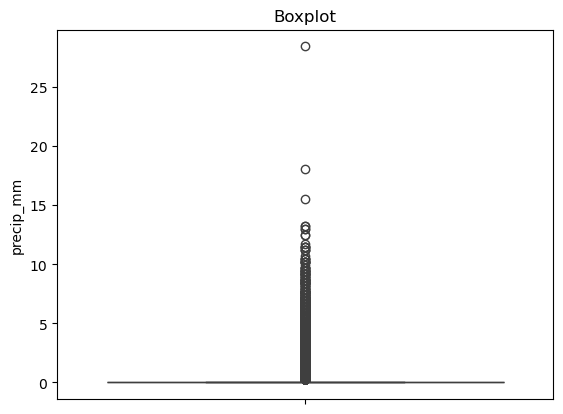

In [50]:
precip_all['precip_mm'].max    
sns.boxplot(data=precip_all['precip_mm'])
plt.title('Boxplot')
plt.show()

In [51]:
USGS_precip_huge = duckdb.query("""
    SELECT
        *
    FROM precip_all
    WHERE precip_mm BETWEEN 10 AND 30
    ORDER BY timestamp_central
""").df()

USGS_precip_huge_wstations = duckdb.query("""
    SELECT
        h.monitoring_location_id AS usgs_id,
        h.precip_mm AS usgs_mmprecip_lag5m,
        h.timestamp_central,
        i.monitoring_location_name AS station_name,
        i.y AS station_lat,
        i.x AS station_lon
    FROM USGS_precip_huge h
    JOIN USGS_station_info i ON h.monitoring_location_id = i.id            
""").df()

USGS_station_info
USGS_precip_huge_wstations
# fig, ax = plt.subplots(figsize=(14, 4))
# ax.plot(USGS_precip_huge['timestamp_central'], USGS_precip_huge['precip_mm'], linewidth=0.6)
# ax.set_title(f"Precipitation")
# ax.set_xlabel("Time (Central)")
# ax.set_ylabel("Precipitation (in)")
# plt.tight_layout()
# plt.show()

,usgs_id,usgs_mmprecip_lag5m,timestamp_central,station_name,station_lat,station_lon
0,USGS-420119087445101,11.684,2021-06-20 23:25:00-05:00,"RAIN GAGE AT OAKTON COLLEGE AT SKOKIE, IL",42.021944,-87.747500
1,USGS-420119087445101,10.414,2021-06-20 23:30:00-05:00,"RAIN GAGE AT OAKTON COLLEGE AT SKOKIE, IL",42.021944,-87.747500
2,USGS-414542087380901,10.414,2021-06-20 23:50:00-05:00,"RAIN GAGE AT HAMILTON PARK AT CHICAGO, IL",41.761667,-87.635833
3,USGS-415155087451901,12.954,2021-06-26 11:50:00-05:00,"RAIN GAGE AT CICERO, IL",41.865278,-87.755278
4,USGS-415657087382101,11.430,2021-06-26 12:00:00-05:00,"RAIN GAGE AT LAKE VIEW, IL",41.949167,-87.639167
5,USGS-415657087382101,10.160,2021-06-26 12:05:00-05:00,"RAIN GAGE AT LAKE VIEW, IL",41.949167,-87.639167
6,USGS-415155087451901,10.160,2021-07-24 17:00:00-05:00,"RAIN GAGE AT CICERO, IL",41.865278,-87.755278
7,USGS-414527087323801,28.448,2021-08-18 11:35:00-05:00,"RAIN GAGE AT SOUTH SHORE, IL",41.757500,-87.543889
8,USGS-415155087451901,13.208,2022-07-23 06:05:00-05:00,"RAIN GAGE AT CICERO, IL",41.865278,-87.755278
9,USGS-414542087380901,13.208,2022-07-23 06:15:00-05:00,"RAIN GAGE AT HAMILTON PARK AT CHICAGO, IL",41.761667,-87.635833


In [52]:
# USGS_station_info

In [53]:
#hourly accumulation per station
# USGS_precip_hourly = duckdb.query("""
#     SELECT
#         monitoring_location_id AS monitoring_location,
#         DATE_TRUNC('hour', timestamp_central) AS timestamp_central,
#         SUM(precip_in * 25.4)                AS USGS_hourly_precip_mm
#     FROM precip_all
#     GROUP BY
#         monitoring_location_id,
#         DATE_TRUNC('hour', timestamp_central)
#     ORDER BY
#         monitoring_location_id,
#         timestamp_central
# """).df()


In [54]:
# precip_hourly 

In [55]:
#jsut checking conversion:
# print(precip_hourly.shape[0])
# print(precip_all.shape[0] / 12)
# print(precip_hourly['timestamp_central'].dt.minute.unique())

In [56]:
#export to csv for eda and combining into model
# precip_hourly.to_csv("data/prepared_data/usgs_hourly_precip.csv", index=False)

In [57]:
#adds station lat and lon and correct naming
usgs_precip_final = duckdb.query("""
    SELECT
        h.monitoring_location_id AS usgs_id,
        h.precip_mm AS usgs_mmprecip_sum5m,
        h.timestamp_central,
        i.monitoring_location_name AS station_name,
        i.y AS station_lat,
        i.x AS station_lon
    FROM precip_all h
    JOIN USGS_station_info i ON h.monitoring_location_id = i.id            
""").df()


In [58]:
usgs_precip_final['station_name'] = usgs_precip_final['station_name'].str.replace(" ","_").str.replace(",_IL","").str.lower().str.replace("rain_gage_at_","").copy()

In [63]:
usgs_precip_final

,usgs_id,usgs_mmprecip_sum5m,timestamp_central,station_name,station_lat,station_lon
0,USGS-414527087323801,0.254,2025-08-11 23:55:00-05:00,south_shore,41.757500,-87.543889
1,USGS-414527087323801,0.000,2025-08-12 00:00:00-05:00,south_shore,41.757500,-87.543889
2,USGS-414527087323801,0.000,2025-08-12 00:05:00-05:00,south_shore,41.757500,-87.543889
3,USGS-414527087323801,0.000,2025-08-12 00:10:00-05:00,south_shore,41.757500,-87.543889
4,USGS-414527087323801,0.000,2025-08-12 00:15:00-05:00,south_shore,41.757500,-87.543889
...,...,...,...,...,...,...
1825932,USGS-420119087445101,0.000,2024-06-26 23:10:00-05:00,oakton_college_at_skokie,42.021944,-87.747500
1825933,USGS-420119087445101,0.000,2024-06-26 23:15:00-05:00,oakton_college_at_skokie,42.021944,-87.747500
1825934,USGS-420119087445101,0.000,2024-06-26 23:20:00-05:00,oakton_college_at_skokie,42.021944,-87.747500
1825935,USGS-420119087445101,0.000,2024-06-26 23:25:00-05:00,oakton_college_at_skokie,42.021944,-87.747500


In [60]:
usgs_precip_final.to_parquet("data/prepared_data/usgs_precip.parquet", index=False)

I'm going to implement a feature naming convention now: 
 Feature naming convention for this project:

     {source}_{variable}_{operation}_{window}

 - source:    where the data came from (coc, usgs, beach, season, etc.)

 - variable:  what's being measured (precip, temp, wind, etc.)

 - operation: how it was aggregated (sum, max, mean, count, lag)
 
 - window:    over what time period (24h, 7d, 6h)

 Examples:

   coc_precip_sum_24h     -> sum of COC precip over 24h before sample

   coc_precip_max_6h      -> max single-bucket COC precip in last 6h

   usgs_precip_sum_7d     -> sum of USGS precip over 7 days

   season_sin_doy         -> sin of day-of-year (no source/window needed)

 Rule: if you change ONE thing about a feature, only ONE slot in the
 name should change. This makes filtering by prefix easy.